In [1]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn nltk accelerate -q

In [2]:
import os
import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
import nltk
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("NOTE: Training on CPU will be slow. Enable GPU in Runtime > Change runtime type.")

TRAIN_SIZE    = 2000
TEST_SIZE     =  500
BATCH_SIZE    =    4
EPOCHS        =    3
LR            = 2e-5
WARMUP_RATIO  = 0.10
CHUNK_SIZE    = 510
STRIDE        = 256
MAX_CHUNKS    =   4
MAX_SENTENCES =  20
MAX_SENT_LEN  = 128

print("\nHyper-parameters loaded.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Hyper-parameters loaded.


Loading IMDb …


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (934 > 512). Running this sequence through the model will result in indexing errors



Analysing token lengths …
  Mean          : 304 tokens
  Median        : 228 tokens
  Max           : 1181 tokens
  Exceed 512    : 40 / 300 (13.3%) ← TRUNCATED by baseline


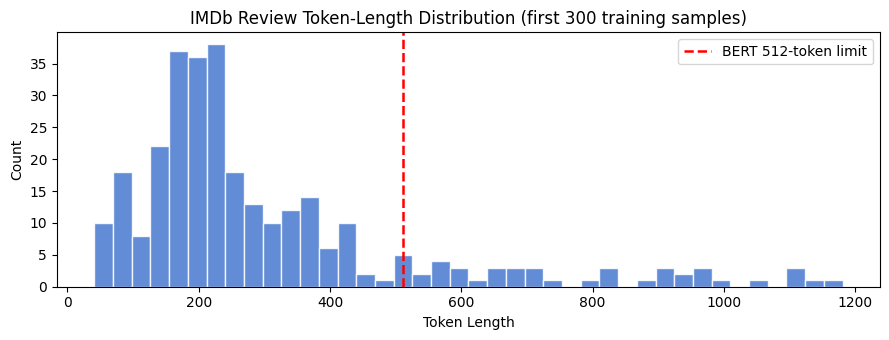

Saved: token_distribution.png


In [3]:
print("Loading IMDb …")
imdb       = load_dataset("imdb")
train_data = imdb["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_data  = imdb["test" ].shuffle(seed=SEED).select(range(TEST_SIZE))
print(f"  Train : {len(train_data)} samples")
print(f"  Test  : {len(test_data)}  samples")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("\nAnalysing token lengths …")
sample_texts  = train_data["text"][:300]
tok_lengths   = [len(tokenizer.tokenize(t)) for t in sample_texts]

over_512 = sum(l > 512 for l in tok_lengths)
print(f"  Mean          : {np.mean(tok_lengths):.0f} tokens")
print(f"  Median        : {np.median(tok_lengths):.0f} tokens")
print(f"  Max           : {np.max(tok_lengths)} tokens")
print(f"  Exceed 512    : {over_512} / {len(tok_lengths)} ({over_512/len(tok_lengths)*100:.1f}%) ← TRUNCATED by baseline")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(tok_lengths, bins=40, color="#4878CF", edgecolor="white", alpha=0.85)
ax.axvline(512, color="red", linestyle="--", lw=1.8, label="BERT 512-token limit")
ax.set_xlabel("Token Length")
ax.set_ylabel("Count")
ax.set_title("IMDb Review Token-Length Distribution (first 300 training samples)")
ax.legend()
plt.tight_layout()
plt.savefig("token_distribution.png", dpi=130)
plt.show()
print("Saved: token_distribution.png")

In [4]:
class BaselineDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=512):
        self.data      = data
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text  = self.data[idx]["text"]
        label = self.data[idx]["label"]
        enc   = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"         : torch.tensor(label, dtype=torch.long),
        }


class SlidingWindowDataset(Dataset):
    def __init__(self, data, tokenizer,
                 chunk_size=CHUNK_SIZE, stride=STRIDE, max_chunks=MAX_CHUNKS):
        self.data       = data
        self.tokenizer  = tokenizer
        self.chunk_size = chunk_size
        self.stride     = stride
        self.max_chunks = max_chunks
        self.seq_len    = chunk_size + 2        # +2 for [CLS] and [SEP]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text  = self.data[idx]["text"]
        label = self.data[idx]["label"]

        tokens   = self.tokenizer.encode(text, add_special_tokens=False)
        ids_list, mask_list = [], []

        start = 0
        while start < len(tokens) and len(ids_list) < self.max_chunks:
            end   = min(start + self.chunk_size, len(tokens))
            chunk = ([self.tokenizer.cls_token_id]
                     + tokens[start:end]
                     + [self.tokenizer.sep_token_id])
            pad   = self.seq_len - len(chunk)
            mask  = [1] * len(chunk) + [0] * pad
            chunk = chunk + [self.tokenizer.pad_token_id] * pad
            ids_list.append(chunk)
            mask_list.append(mask)
            if end == len(tokens):
                break
            start += self.stride

        actual_chunks = len(ids_list)
        while len(ids_list) < self.max_chunks:
            ids_list.append( [self.tokenizer.pad_token_id] * self.seq_len)
            mask_list.append([0]                           * self.seq_len)

        return {
            "input_ids"     : torch.tensor(ids_list,   dtype=torch.long),
            "attention_mask": torch.tensor(mask_list,  dtype=torch.long),
            "label"         : torch.tensor(label,      dtype=torch.long),
            "num_chunks"    : torch.tensor(actual_chunks, dtype=torch.long),
        }


class HierarchicalDataset(Dataset):
    def __init__(self, data, tokenizer,
                 max_sentences=MAX_SENTENCES, max_sent_len=MAX_SENT_LEN):
        self.data          = data
        self.tokenizer     = tokenizer
        self.max_sentences = max_sentences
        self.max_sent_len  = max_sent_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text          = self.data[idx]["text"]
        label         = self.data[idx]["label"]
        sentences     = sent_tokenize(text)[:self.max_sentences]
        actual_sents  = len(sentences)

        ids_list, mask_list = [], []
        for sent in sentences:
            enc = self.tokenizer(
                sent,
                max_length=self.max_sent_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            ids_list.append( enc["input_ids"].squeeze(0))
            mask_list.append(enc["attention_mask"].squeeze(0))
        pad_ids  = torch.zeros(self.max_sent_len, dtype=torch.long)
        pad_mask = torch.zeros(self.max_sent_len, dtype=torch.long)
        while len(ids_list) < self.max_sentences:
            ids_list.append(pad_ids)
            mask_list.append(pad_mask)

        return {
            "input_ids"     : torch.stack(ids_list),
            "attention_mask": torch.stack(mask_list),
            "label"         : torch.tensor(label,       dtype=torch.long),
            "num_sentences" : torch.tensor(actual_sents, dtype=torch.long),
        }
print("Dataset classes defined: BaselineDataset | SlidingWindowDataset | HierarchicalDataset")

Dataset classes defined: BaselineDataset | SlidingWindowDataset | HierarchicalDataset


In [5]:
def count_params(model):
    """Return trainable parameter count."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class BaselineBERT(nn.Module):
    """
    Fine-tunes BERT for binary classification using the [CLS] pooler output.
    Input texts longer than 512 tokens are silently truncated by the tokeniser.
    Serves as the performance floor for long-document handling.
    """
    def __init__(self, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.drop       = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask, **_):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.drop(out.pooler_output))


class SlidingWindowBERT(nn.Module):
    def __init__(self, pooling="mean", num_labels=2, dropout=0.3):
        super().__init__()
        assert pooling in ("mean", "max")
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.pooling    = pooling
        self.drop       = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask, num_chunks, **_):
        B, C, L = input_ids.shape
        ids_flat  = input_ids.view(B * C, L)
        mask_flat = attention_mask.view(B * C, L)

        cls_embs  = self.bert(input_ids=ids_flat,
                              attention_mask=mask_flat).pooler_output
        cls_embs  = cls_embs.view(B, C, 768)

        valid = torch.zeros(B, C, 1, device=input_ids.device)
        for i, n in enumerate(num_chunks):
            valid[i, :n.item()] = 1.0

        if self.pooling == "mean":
            pooled = (cls_embs * valid).sum(1) / valid.sum(1).clamp(min=1)
        else:
            cls_embs = cls_embs.masked_fill(valid == 0, float("-inf"))
            pooled   = cls_embs.max(dim=1).values

        return self.classifier(self.drop(pooled))


class HierarchicalBERT(nn.Module):
    def __init__(self, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        enc_layer = nn.TransformerEncoderLayer(
            d_model=768, nhead=8,
            dim_feedforward=2048,
            dropout=dropout,
            batch_first=True,
        )
        self.doc_encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.drop        = nn.Dropout(dropout)
        self.classifier  = nn.Linear(768, num_labels)
    def forward(self, input_ids, attention_mask, num_sentences, **_):
        B, S, L = input_ids.shape

        ids_flat  = input_ids.view(B * S, L)
        mask_flat = attention_mask.view(B * S, L)

        sent_embs = self.bert(input_ids=ids_flat,
                              attention_mask=mask_flat).pooler_output
        sent_embs = sent_embs.view(B, S, 768)

        pad_mask = torch.ones(B, S, dtype=torch.bool, device=input_ids.device)
        for i, n in enumerate(num_sentences):
            pad_mask[i, :n.item()] = False

        doc_out = self.doc_encoder(sent_embs, src_key_padding_mask=pad_mask)

        valid  = (~pad_mask).float().unsqueeze(-1)
        pooled = (doc_out * valid).sum(1) / valid.sum(1).clamp(min=1)

        return self.classifier(self.drop(pooled))

for cls, kwargs in [
    (BaselineBERT,      {}),
    (SlidingWindowBERT, {"pooling": "mean"}),
    (HierarchicalBERT,  {}),
]:
    m = cls(**kwargs)
    print(f"  {cls.__name__:<25} {count_params(m):>13,} trainable parameters")
    del m

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BaselineBERT                109,483,778 trainable parameters


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  SlidingWindowBERT           109,483,778 trainable parameters


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  HierarchicalBERT            120,511,746 trainable parameters


In [6]:
LOSS_FN = nn.CrossEntropyLoss()

def _infer_model_type(model):
    """Infer which forward-pass signature to use from the model class."""
    name = type(model).__name__.lower()
    if "baseline" in name:
        return "baseline"
    if "sliding" in name:
        return model.pooling
    return "hierarchical"

def _forward(model, batch, mtype):
    """Route a batch through the correct model signature."""
    ids   = batch["input_ids"].to(device)
    masks = batch["attention_mask"].to(device)
    if mtype == "baseline":
        return model(ids, masks)
    if mtype in ("mean", "max"):
        return model(ids, masks, num_chunks=batch["num_chunks"].to(device))
    return model(ids, masks, num_sentences=batch["num_sentences"].to(device))

def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    mtype      = _infer_model_type(model)
    total_loss = 0.0
    for batch in loader:
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        loss = LOSS_FN(_forward(model, batch, mtype), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    mtype      = _infer_model_type(model)
    preds_all, labels_all = [], []
    for batch in loader:
        preds = _forward(model, batch, mtype).argmax(dim=1)
        preds_all.extend( preds.cpu().numpy())
        labels_all.extend(batch["label"].numpy())
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average="weighted")
    return acc, f1

def train_model(model, train_loader, test_loader, label=""):
    optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps  = int(WARMUP_RATIO * total_steps),
        num_training_steps= total_steps,
    )
    history, t0 = [], time.time()
    for epoch in range(1, EPOCHS + 1):
        loss    = train_one_epoch(model, train_loader, optimizer, scheduler)
        acc, f1 = evaluate(model, test_loader)
        elapsed = time.time() - t0
        history.append(dict(epoch=epoch, loss=loss, acc=acc, f1=f1))
        print(f"  [{label}] Epoch {epoch}/{EPOCHS}  "
              f"loss={loss:.4f}  acc={acc:.4f}  f1={f1:.4f}  "
              f"({elapsed:.0f}s elapsed)")
    final_acc, final_f1 = evaluate(model, test_loader)
    return {
        "label"        : label,
        "accuracy"     : final_acc,
        "f1"           : final_f1,
        "training_time": time.time() - t0,
        "parameters"   : count_params(model),
        "history"      : history,
    }
print("Training utilities ready.")

Training utilities ready.


In [7]:
print("=" * 60)
print(" Model 1 : Baseline BERT — Truncation @ 512 tokens")
print("=" * 60)

bl_train_ds = BaselineDataset(train_data, tokenizer)
bl_test_ds  = BaselineDataset(test_data,  tokenizer)
bl_train_dl = DataLoader(bl_train_ds, batch_size=BATCH_SIZE,
                         shuffle=True,  num_workers=2, pin_memory=True)
bl_test_dl  = DataLoader(bl_test_ds,  batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

baseline_model   = BaselineBERT().to(device)
baseline_results = train_model(baseline_model, bl_train_dl, bl_test_dl,
                               label="Baseline")
print(f"\nBaseline  →  Acc: {baseline_results['accuracy']:.4f}  "
      f"F1: {baseline_results['f1']:.4f}  "
      f"Time: {baseline_results['training_time']:.0f}s  "
      f"Params: {baseline_results['parameters']:,}")

del baseline_model
torch.cuda.empty_cache()

 Model 1 : Baseline BERT — Truncation @ 512 tokens


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Baseline] Epoch 1/3  loss=0.5374  acc=0.9080  f1=0.9080  (233s elapsed)
  [Baseline] Epoch 2/3  loss=0.2437  acc=0.9100  f1=0.9099  (485s elapsed)
  [Baseline] Epoch 3/3  loss=0.1341  acc=0.9140  f1=0.9140  (736s elapsed)

Baseline  →  Acc: 0.9140  F1: 0.9140  Time: 755s  Params: 109,483,778


In [8]:
print("=" * 60)
print(" Model 2 : Sliding Window BERT — Mean Pooling")
print(f"           chunk_size={CHUNK_SIZE}  stride={STRIDE}  max_chunks={MAX_CHUNKS}")
print("=" * 60)

sw_train_ds = SlidingWindowDataset(train_data, tokenizer)
sw_test_ds  = SlidingWindowDataset(test_data,  tokenizer)
sw_train_dl = DataLoader(sw_train_ds, batch_size=BATCH_SIZE,
                         shuffle=True,  num_workers=2, pin_memory=True)
sw_test_dl  = DataLoader(sw_test_ds,  batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

sw_mean_model   = SlidingWindowBERT(pooling="mean").to(device)
sw_mean_results = train_model(sw_mean_model, sw_train_dl, sw_test_dl,
                              label="SW-Mean")
print(f"\nSW-Mean  →  Acc: {sw_mean_results['accuracy']:.4f}  "
      f"F1: {sw_mean_results['f1']:.4f}  "
      f"Time: {sw_mean_results['training_time']:.0f}s  "
      f"Params: {sw_mean_results['parameters']:,}")

del sw_mean_model
torch.cuda.empty_cache()

 Model 2 : Sliding Window BERT — Mean Pooling
           chunk_size=510  stride=256  max_chunks=4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [SW-Mean] Epoch 1/3  loss=0.4950  acc=0.8720  f1=0.8709  (908s elapsed)
  [SW-Mean] Epoch 2/3  loss=0.2552  acc=0.9080  f1=0.9080  (1819s elapsed)
  [SW-Mean] Epoch 3/3  loss=0.0932  acc=0.9020  f1=0.9020  (2732s elapsed)

SW-Mean  →  Acc: 0.9020  F1: 0.9020  Time: 2805s  Params: 109,483,778


In [9]:
print("=" * 60)
print(" Model 3 : Sliding Window BERT — Max Pooling")
print(f"           chunk_size={CHUNK_SIZE}  stride={STRIDE}  max_chunks={MAX_CHUNKS}")
print("=" * 60)
sw_max_model   = SlidingWindowBERT(pooling="max").to(device)
sw_max_results = train_model(sw_max_model, sw_train_dl, sw_test_dl,
                             label="SW-Max")
print(f"\nSW-Max   →  Acc: {sw_max_results['accuracy']:.4f}  "
      f"F1: {sw_max_results['f1']:.4f}  "
      f"Time: {sw_max_results['training_time']:.0f}s  "
      f"Params: {sw_max_results['parameters']:,}")

del sw_max_model
torch.cuda.empty_cache()

 Model 3 : Sliding Window BERT — Max Pooling
           chunk_size=510  stride=256  max_chunks=4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [SW-Max] Epoch 1/3  loss=0.4700  acc=0.8920  f1=0.8920  (910s elapsed)
  [SW-Max] Epoch 2/3  loss=0.2870  acc=0.9120  f1=0.9120  (1820s elapsed)
  [SW-Max] Epoch 3/3  loss=0.1272  acc=0.9020  f1=0.9020  (2730s elapsed)

SW-Max   →  Acc: 0.9020  F1: 0.9020  Time: 2803s  Params: 109,483,778


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# 10. Train Model 4 — Hierarchical BERT  [Extension]
# ════════════════════════════════════════════════════════════════════════════
#print("=" * 60)
#print(" Model 4 : Hierarchical BERT (Sentence-level → Document-level)")
#print(f"           max_sentences={MAX_SENTENCES}  max_sent_len={MAX_SENT_LEN}")
#print("=" * 60)

#hi_train_ds = HierarchicalDataset(train_data, tokenizer)
#hi_test_ds  = HierarchicalDataset(test_data,  tokenizer)
#hi_train_dl = DataLoader(hi_train_ds, batch_size=BATCH_SIZE,
#                         shuffle=True,  num_workers=2, pin_memory=True)
#hi_test_dl  = DataLoader(hi_test_ds,  batch_size=BATCH_SIZE,
#                         shuffle=False, num_workers=2, pin_memory=True)

#hier_model   = HierarchicalBERT().to(device)
#hier_results = train_model(hier_model, hi_train_dl, hi_test_dl,
#                           label="Hierarchical")
#print(f"\nHierarch →  Acc: {hier_results['accuracy']:.4f}  "
#      f"F1: {hier_results['f1']:.4f}  "
#      f"Time: {hier_results['training_time']:.0f}s  "
#      f"Params: {hier_results['parameters']:,}")

#del hier_model
#torch.cuda.empty_cache()

In [17]:
all_results = [baseline_results, sw_mean_results, sw_max_results]
rows = [
    {
        "Model"            : "Baseline BERT (Truncated)",
        "Approach"         : "Hard truncation @ 512 tokens",
        "Accuracy"         : f"{baseline_results['accuracy']:.4f}",
        "F1 Score"         : f"{baseline_results['f1']:.4f}",
        "Training Time (s)": f"{baseline_results['training_time']:.0f}",
        "Parameters"       : f"{baseline_results['parameters']:,}",
    },
    {
        "Model"            : "Sliding Window — Mean Pool",
        "Approach"         : f"Chunks ({CHUNK_SIZE}t, stride {STRIDE}), mean-pool CLS",
        "Accuracy"         : f"{sw_mean_results['accuracy']:.4f}",
        "F1 Score"         : f"{sw_mean_results['f1']:.4f}",
        "Training Time (s)": f"{sw_mean_results['training_time']:.0f}",
        "Parameters"       : f"{sw_mean_results['parameters']:,}",
    },
    {
        "Model"            : "Sliding Window — Max Pool",
        "Approach"         : f"Chunks ({CHUNK_SIZE}t, stride {STRIDE}), max-pool CLS",
        "Accuracy"         : f"{sw_max_results['accuracy']:.4f}",
        "F1 Score"         : f"{sw_max_results['f1']:.4f}",
        "Training Time (s)": f"{sw_max_results['training_time']:.0f}",
        "Parameters"       : f"{sw_max_results['parameters']:,}",
    }
]
df = pd.DataFrame(rows)
print("\n" + "=" * 90)
print("RESULTS SUMMARY — CSE39 Part 2: Long Sequence Limitation")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)
df.to_csv("results_summary.csv", index=False)
print("\nSaved: results_summary.csv")
accs = [r["accuracy"] for r in all_results]
f1s  = [r["f1"]       for r in all_results]
lbls = [r["label"] for r in all_results]
print(f"\nBest Accuracy : {lbls[int(np.argmax(accs))]} ({max(accs):.4f})")
print(f"Best F1 Score : {lbls[int(np.argmax(f1s))]}  ({max(f1s):.4f})")


RESULTS SUMMARY — CSE39 Part 2: Long Sequence Limitation
                     Model                                 Approach Accuracy F1 Score Training Time (s)  Parameters
 Baseline BERT (Truncated)             Hard truncation @ 512 tokens   0.9140   0.9140               755 109,483,778
Sliding Window — Mean Pool Chunks (510t, stride 256), mean-pool CLS   0.9020   0.9020              2805 109,483,778
 Sliding Window — Max Pool  Chunks (510t, stride 256), max-pool CLS   0.9020   0.9020              2803 109,483,778

Saved: results_summary.csv

Best Accuracy : Baseline (0.9140)
Best F1 Score : Baseline  (0.9140)


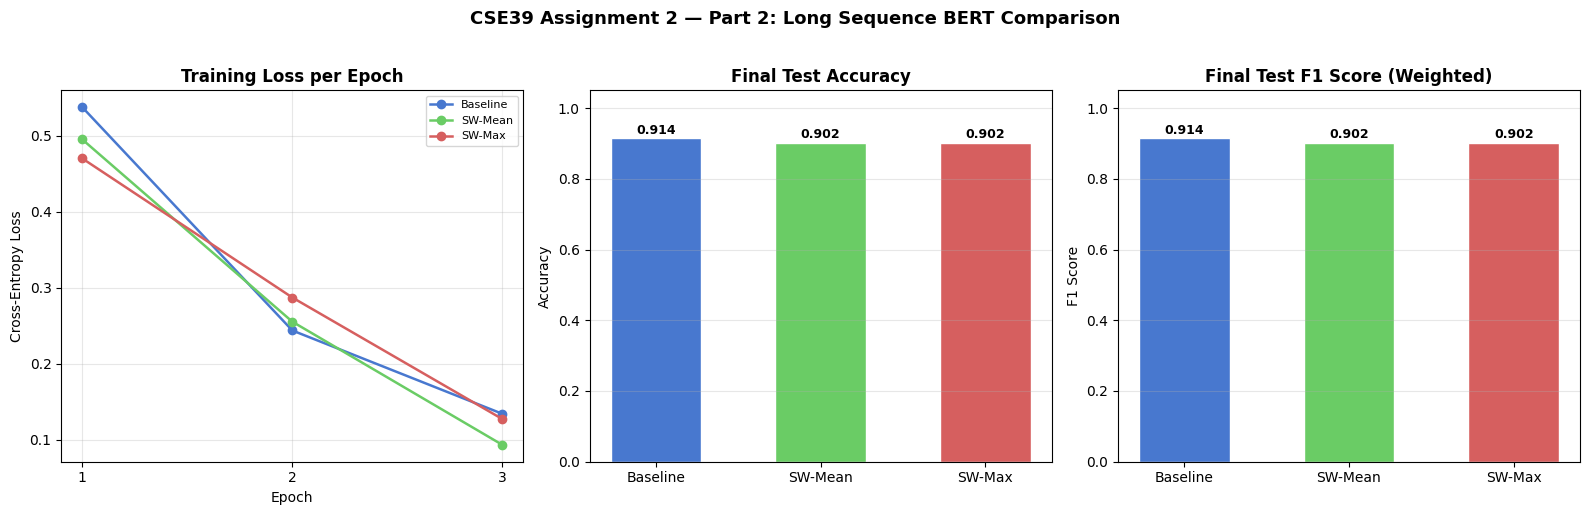

Saved: comparison_plots.png


In [19]:

COLORS      = ["#4878CF", "#6ACC65", "#D65F5F"]
MODEL_NAMES = ["Baseline", "SW-Mean", "SW-Max"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
for r, name, col in zip(all_results, MODEL_NAMES, COLORS):
    xs = [h["epoch"] for h in r["history"]]
    ys = [h["loss"]  for h in r["history"]]
    ax.plot(xs, ys, marker="o", lw=1.8, label=name, color=col)
ax.set_title("Training Loss per Epoch", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
accs = [r["accuracy"] for r in all_results]
bars = ax.bar(MODEL_NAMES, accs, color=COLORS, edgecolor="white", width=0.55)
ax.set_ylim(0, 1.05); ax.set_title("Final Test Accuracy", fontweight="bold")
ax.set_ylabel("Accuracy"); ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

ax = axes[2]
f1s  = [r["f1"] for r in all_results]
bars = ax.bar(MODEL_NAMES, f1s, color=COLORS, edgecolor="white", width=0.55)
ax.set_ylim(0, 1.05); ax.set_title("Final Test F1 Score (Weighted)", fontweight="bold")
ax.set_ylabel("F1 Score"); ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle(
    "CSE39 Assignment 2 — Part 2: Long Sequence BERT Comparison",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("comparison_plots.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: comparison_plots.png")